<a href="https://colab.research.google.com/github/PaolaArraut/Spotify-Mood-Analytics/blob/main/Copy_of_DS_%26_AI_Final_Project_TEMPLATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start your amazing project here

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Find your cool dataset 😎 (15 min)

Recomended:

* [Kaggle](https://www.kaggle.com/datasets?sort=downloadCount&fileType=csv&minUsabilityRating=9.00+or+higher)


#Loading data (5 min)
### Step 1:
###  Upload file on folder icon

### Step 2:
###  Copy uploaded file path

### Step 3:
###  Load data into pandas dataframe using file path



In [ ]:
# create df here
df = pd.read_csv("/content/imdb_movies.csv", sep=",")
df.head()


,0
names,0
date_x,0
score,0
genre,85
overview,0
crew,56
orig_title,0
status,0
orig_lang,0
budget_x,0


## EDA Process (60 min)
### Helpful questions for analysis:
###

*   How many columns do you have?

*   How many rows?
* What type of data?
* What are the main columns?


*   How many missing values do you have?
*   What's your data's distribution (graph a single attribute/feature of the data)?
* *  Histogram
* * Bar chart
* * Pie chart
* Which attributes are strongly correlated / related?

* Identify target feature?

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(100,100))
#Categorical variables are encoded into numerical variables
#df_encoded = pd.get_dummies(df, columns=['status', 'orig_lang', 'country'], drop_first=False)
df_encoded = pd.get_dummies(df, columns=['status'], drop_first=False)
df_encoded = df_encoded.drop(columns=['names','date_x','genre','overview'], axis=1)

sns.heatmap(df_encoded.corr())



ValueError: could not convert string to float: "Michael B. Jordan, Adonis Creed, Tessa Thompson, Bianca Taylor, Jonathan Majors, Damien Anderson, Wood Harris, Tony 'Little Duke' Evers, Phylicia Rashād, Mary Anne Creed, Mila Davis-Kent, Amara Creed, Florian Munteanu, Viktor Drago, José Benavidez Jr., Felix Chavez, Selenis Leyva, Laura Chavez"

<Figure size 10000x10000 with 0 Axes>

/tmp/ipython-input-4215588567.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["revenue"] = (df["revenue"] - df["revenue"].min()) / (df["revenue"].max() - df["revenue"].min())
/tmp/ipython-input-4215588567.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["budget_x"] = (df["budget_x"] - df["budget_x"].min()) / (df["budget_x"].max() - df["budget_x"].min())


<Axes: title={'center': 'Revenue for film'}, xlabel='film', ylabel='frequency'>

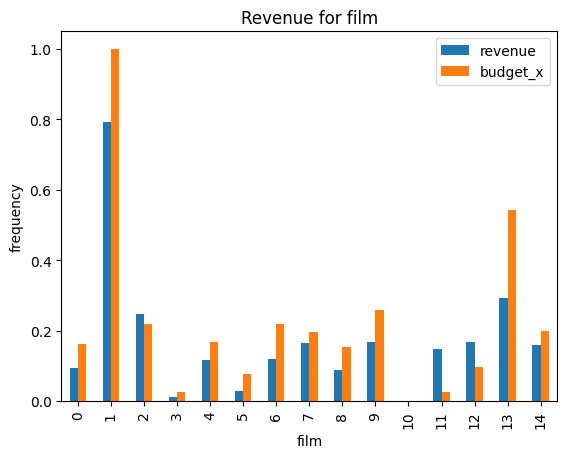

In [ ]:
# Code your EDA process here

tmp_df = df[["revenue", "budget_x"]]

#Min-Max scalling
tmp_df["revenue"] = (df["revenue"] - df["revenue"].min()) / (df["revenue"].max() - df["revenue"].min())
tmp_df["budget_x"] = (df["budget_x"] - df["budget_x"].min()) / (df["budget_x"].max() - df["budget_x"].min())




tmp_df[:15].plot(kind='bar', ylabel="frequency", xlabel="film", title="Revenue for film")

# DATA CLEANING (45 min)
* Remove any unecessary columns
* Combine very similar columns (Aggregation)
* Identify Outliers (Use IQR formula)
* Remove Duplicates
* Replace or remove rows with missing values
* * KNN (Imputation)
* * median (Imputation)
* * mean (Imputation)
* * Forward fill (time-series imputation)
* * Backward fill (time-series imputation)
* * Linear interpolation (time-series imputation)
* Normalize data-set if needed
* * min-max
* * z-score


In [ ]:
#IQR

Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)

IQR = Q3 - Q1
print(Q1, Q3)
revenue_lower_bound = Q1 - 1.5 * IQR
revenue_upper_bound = Q3 + 1.5 * IQR
print(revenue_lower_bound)
print(revenue_upper_bound)

Q1 = df['budget_x'].quantile(0.25)
Q3 = df['budget_x'].quantile(0.75)

IQR = Q3 - Q1
print(Q1, Q3)
budget_lower_bound = Q1 - 1.5 * IQR
budget_upper_bound = Q3 + 1.5 * IQR
print(budget_lower_bound)
print(budget_upper_bound)

df_outliers = df[(df["revenue"] < revenue_lower_bound) | (df["revenue"] > revenue_upper_bound)
| (df["budget_x"] < budget_lower_bound) | (df["budget_x"] > budget_upper_bound)
                 ]
df_outliers
df_outliers.head()
df_outliers.shape


28588985.0 417802077.1
-555230653.1500001
1001621715.2500001
15000000.0 105000000.0
-120000000.0
240000000.0


(188, 12)

In [ ]:
# Clean data set here
df.isnull().sum()



df_cleaned = df.dropna(axis=1)
df_cleaned = df_cleaned.drop(['date_x','overview', 'orig_title'], axis=1)

#Min-Max scalling for numerical values
df_cleaned["revenue"] = (df_cleaned["revenue"] - df_cleaned["revenue"].min()) / (df_cleaned["revenue"].max() - df_cleaned["revenue"].min())
df_cleaned["budget_x"] = (df_cleaned["budget_x"] - df_cleaned["budget_x"].min()) / (df_cleaned["budget_x"].max() - df_cleaned["budget_x"].min())

df_cleaned.head()

,names,score,status,orig_lang,budget_x,revenue,country
0,Creed III,73.0,Released,English,0.163043,0.092901,AU
1,Avatar: The Way of Water,78.0,Released,English,1.000000,0.792417,AU
2,The Super Mario Bros. Movie,76.0,Released,English,0.217391,0.247788,AU
3,Mummies,70.0,Released,"Spanish, Castilian",0.026739,0.011697,AU
4,Supercell,61.0,Released,English,0.167391,0.116613,US


# MODEL BUILDING (45 min)
## Best on your data and target feature, try to choose the best model

* Classification Models
* * Decision trees
* * Rule based classfiers
* * KNN
* * Naive bayes
* * Nueral Networks
* * Support Vector Machine (SVM)

* Clustering
* * K-means
* * K-means ++
* * DB Scan
* * Hierarchical clustering
* * Gaussian mixture

* Regression
* * Linear Regression
* * Polynomial Regression
* * Oridnary Least Squares

In [ ]:
# Split data into training and testing
from sklearn.model_selection import train_test_split



# Build model here

# MODEL EVALUATION (25 min)


## Classification and Regression
* Accuracy
* Precision @ k
* Recall @ k
* F1 Score
* Confusion Matrix

## Regression
* SSE (Sum of Squares Error)
* SAE (Sum of Absolute Error)

## Clustering
* Sillhoutte Score
* Elbow method

In [ ]:
# Evaluate your model here
from sklearn.metrics import

# Conclusion
